# LEVEL 2
# TASK 1 – Predicting House Prices with Linear Regression

## Objective

Build and evaluate a Linear Regression model that predicts house prices based on features such as area, location, number of rooms, and age.

## Tech Stack

- Python
- pandas
- NumPy
- scikit-learn
- Matplotlib
- Jupyter Notebook

## Project Overview

In this project, we will inspect and clean the house price dataset, identify useful predictive features, handle missing values and categorical variables, analyse correlations, train a Linear Regression model, evaluate its performance, visualize actual versus predicted prices, analyse residuals, and interpret the model coefficients.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("House_Prices.csv")
df.head()

,OverallQual,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,TotalBsmtSF,Neighborhood,CentralAir,SalePrice
0,10,1308,1,1,2016,1.0,1003.0,Central,Y,471700.0
1,6,1577,1,1,1950,3.0,576.0,East,Y,339150.0
2,10,1739,3,2,2002,1.0,NaN,Central,Y,496746.0
3,9,1096,3,2,1972,0.0,379.0,West,Y,358029.0
4,8,1962,4,2,1964,1.0,824.0,North,Y,468573.0


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 600
Number of columns: 10

Column names:
['OverallQual', 'GrLivArea', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'Neighborhood', 'CentralAir', 'SalePrice']

Data types:
OverallQual       int64
GrLivArea         int64
BedroomAbvGr      int64
FullBath          int64
YearBuilt         int64
GarageCars      float64
TotalBsmtSF     float64
Neighborhood     object
CentralAir       object
SalePrice       float64
dtype: object

Missing values:
OverallQual      0
GrLivArea        0
BedroomAbvGr     0
FullBath         0
YearBuilt        0
GarageCars       8
TotalBsmtSF     10
Neighborhood     6
CentralAir       0
SalePrice        0
dtype: int64


In [4]:
print("Descriptive Statistics:")
print(df.describe())
print("\nSalePrice statistics:")
print("Mean:", df["SalePrice"].mean())
print("Median:", df["SalePrice"].median())
print("Minimum:", df["SalePrice"].min())
print("Maximum:", df["SalePrice"].max())

Descriptive Statistics:
       OverallQual    GrLivArea  BedroomAbvGr    FullBath    YearBuilt  \
count   600.000000   600.000000    600.000000  600.000000   600.000000   
mean      6.500000  1605.683333      2.833333    2.170000  1985.818333   
std       2.315658   496.424474      1.210233    0.928729    20.850097   
min       3.000000   500.000000      1.000000    1.000000  1950.000000   
25%       4.750000  1284.000000      2.000000    1.000000  1968.000000   
50%       6.000000  1609.500000      3.000000    2.000000  1987.000000   
75%       9.000000  1926.250000      4.000000    3.000000  2003.250000   
max      10.000000  3005.000000      6.000000    4.000000  2023.000000   

       GarageCars  TotalBsmtSF      SalePrice  
count  592.000000   590.000000     600.000000  
mean     1.359797   812.447458  407693.431667  
std      1.140222   373.068094   81459.727485  
min      0.000000   110.000000  176800.000000  
25%      0.000000   526.000000  353855.500000  
50%      1.000000   7

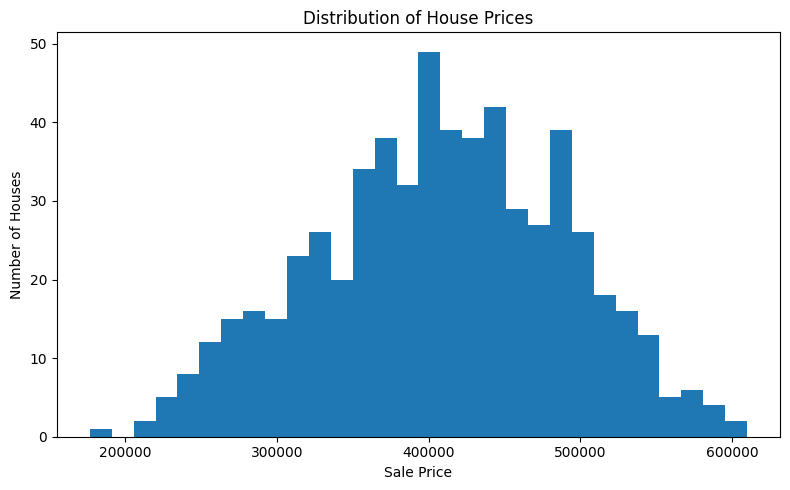

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(df["SalePrice"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

## Feature Selection Discussion

The target variable for this project is `SalePrice`.

The following features were selected as potential predictors:

- **GrLivArea:** Represents above-ground living area and shows a relatively strong relationship with house price.
- **OverallQual:** Represents the overall quality of the house and is strongly related to the target variable.
- **BedroomAbvGr:** Indicates the number of bedrooms above ground and may contribute to price differences.
- **FullBath:** Represents the number of full bathrooms and may influence house value.
- **TotalBsmtSF:** Represents total basement area and has a positive relationship with house price.
- **GarageCars:** Represents garage capacity and may provide additional information about property value.
- **YearBuilt:** Represents the age of the property and may influence price.
- **Neighborhood:** Location is an important categorical characteristic and will be encoded using one-hot encoding.
- **CentralAir:** Availability of central air conditioning is a categorical property feature and will also be encoded.

The final model will use these features after handling missing values and encoding categorical variables.

In [6]:
df["GarageCars"] = df["GarageCars"].fillna(df["GarageCars"].median())
df["TotalBsmtSF"] = df["TotalBsmtSF"].fillna(df["TotalBsmtSF"].median())
print("Missing GarageCars:", df["GarageCars"].isnull().sum())
print("Missing TotalBsmtSF:", df["TotalBsmtSF"].isnull().sum())

Missing GarageCars: 0
Missing TotalBsmtSF: 0


In [7]:
neighborhood_mode = df["Neighborhood"].mode()[0]
df["Neighborhood"] = df["Neighborhood"].fillna(neighborhood_mode)
print("Neighborhood mode:", neighborhood_mode)
print("Missing Neighborhood:", df["Neighborhood"].isnull().sum())

Neighborhood mode: Central
Missing Neighborhood: 0


## Categorical Feature Encoding

The dataset contains two categorical features: `Neighborhood` and `CentralAir`.

These variables cannot be directly used by the Linear Regression model because they contain text categories. Therefore, One-Hot Encoding will be applied to convert each category into numerical indicator columns containing 0 or 1.

The original categorical columns will be removed after encoding to avoid keeping duplicate representations of the same information.

In [8]:
df = pd.get_dummies(
    df,
    columns=["Neighborhood", "CentralAir"],
    drop_first=True,
    dtype=int
)
df.head()

,OverallQual,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,TotalBsmtSF,SalePrice,Neighborhood_East,Neighborhood_North,Neighborhood_South,Neighborhood_West,CentralAir_Y
0,10,1308,1,1,2016,1.0,1003.0,471700.0,0,0,0,0,1
1,6,1577,1,1,1950,3.0,576.0,339150.0,1,0,0,0,1
2,10,1739,3,2,2002,1.0,767.0,496746.0,0,0,0,0,1
3,9,1096,3,2,1972,0.0,379.0,358029.0,0,0,0,1,1
4,8,1962,4,2,1964,1.0,824.0,468573.0,0,1,0,0,1


In [9]:
correlation_columns = [
    "OverallQual",
    "GrLivArea",
    "BedroomAbvGr",
    "FullBath",
    "YearBuilt",
    "GarageCars",
    "TotalBsmtSF",
    "SalePrice"
]

correlation_matrix = df[correlation_columns].corr()
correlation_matrix

,OverallQual,GrLivArea,BedroomAbvGr,FullBath,YearBuilt,GarageCars,TotalBsmtSF,SalePrice
OverallQual,1.000000,0.013104,-0.005957,0.041142,0.016476,0.028307,0.014904,0.637239
GrLivArea,0.013104,1.000000,0.736856,0.645723,-0.040437,-0.006301,0.643387,0.670116
BedroomAbvGr,-0.005957,0.736856,1.000000,0.862961,-0.071861,0.011563,0.498956,0.546263
FullBath,0.041142,0.645723,0.862961,1.000000,-0.048924,-0.016194,0.460040,0.533629
YearBuilt,0.016476,-0.040437,-0.071861,-0.048924,1.000000,-0.004826,-0.010724,0.093806
GarageCars,0.028307,-0.006301,0.011563,-0.016194,-0.004826,1.000000,0.038623,0.133690
TotalBsmtSF,0.014904,0.643387,0.498956,0.460040,-0.010724,0.038623,1.000000,0.499420
SalePrice,0.637239,0.670116,0.546263,0.533629,0.093806,0.133690,0.499420,1.000000


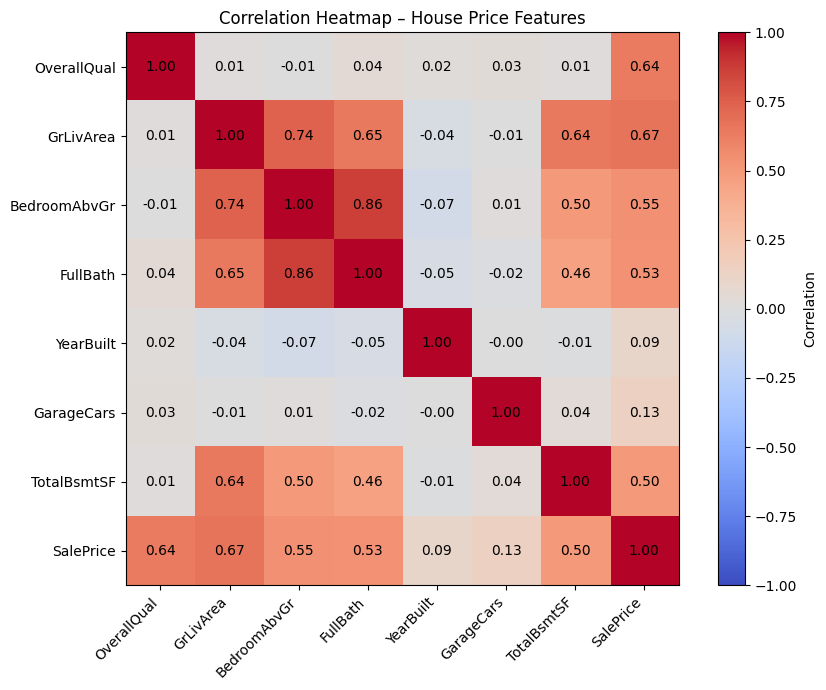

In [10]:
plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )
plt.title("Correlation Heatmap – House Price Features")
plt.tight_layout()
plt.show()

## Correlation Analysis – Key Findings

The correlation analysis shows that `GrLivArea` has the strongest positive correlation with `SalePrice` among the selected numerical features, with a correlation of **0.67**. `OverallQual` also has a relatively strong positive correlation of **0.64**.

Other positive relationships with `SalePrice` include `BedroomAbvGr` (0.55), `FullBath` (0.53), and `TotalBsmtSF` (0.50). `GarageCars` (0.13) and `YearBuilt` (0.09) show relatively weak linear relationships with the target in this dataset.

A strong correlation of **0.86** is also observed between `BedroomAbvGr` and `FullBath`, indicating that these two predictor variables are closely related to each other.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training columns:", X_train.shape[1])
print("Testing columns:", X_test.shape[1])

Training rows: 480
Testing rows: 120
Training columns: 12
Testing columns: 12


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
y_pred = model.predict(X_test)

print("First 10 predicted prices:")
print(y_pred[:10])

First 10 predicted prices:
[347358.79777458 474836.12550402 409449.80948525 448386.9021539
 397933.0736586  383324.17016898 373568.55265612 454849.73934972
 333693.14595651 227984.89106657]


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 677732443.4525691
Root Mean Squared Error (RMSE): 26033.29490196293
R² Score: 0.8781119125462289


## Model Evaluation

The Linear Regression model was evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score.

- **MSE:** 677,732,443.45
- **RMSE:** 26,033.29
- **R² Score:** 0.8781

The R² score indicates that the model explains approximately **87.8% of the variation in house prices** in the test dataset. The RMSE indicates that the model's typical prediction error is approximately **26,033 price units**.

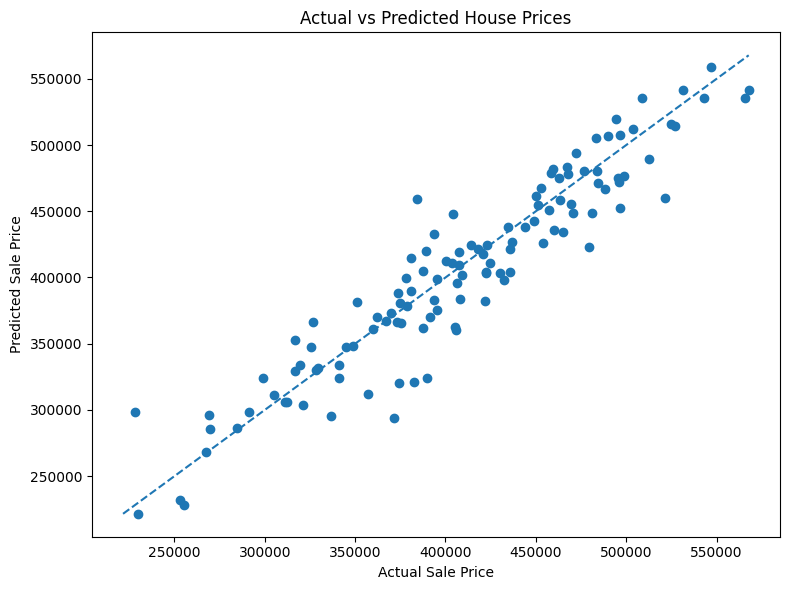

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.tight_layout()
plt.show()

### Observation – Actual vs Predicted Prices

The scatter plot shows that most predicted house prices are reasonably close to the diagonal reference line representing perfect predictions. This indicates that the Linear Regression model captures a substantial portion of the relationship between the selected house features and the actual sale prices.

Some points are noticeably farther from the diagonal line, showing that the model makes larger prediction errors for certain houses.

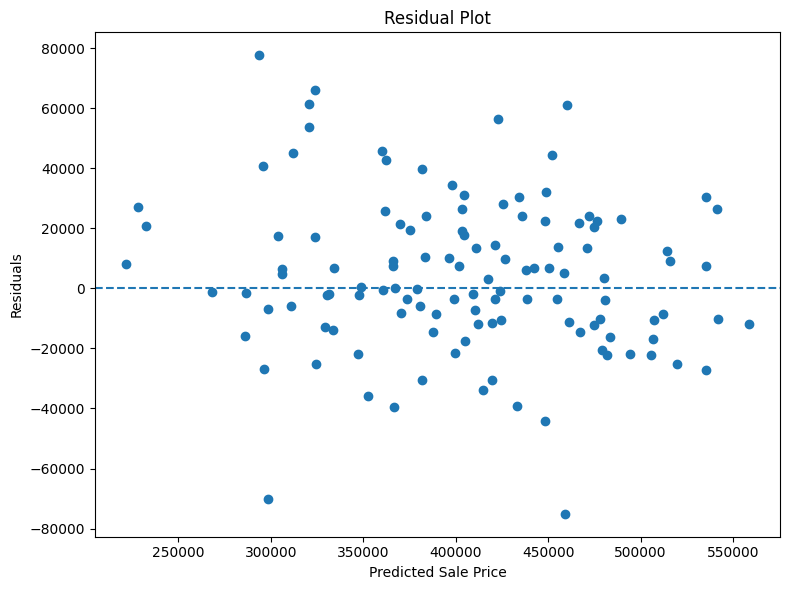

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

### Observation – Residual Plot

The residuals are distributed on both sides of the zero line without a strong visible curved or systematic pattern. This suggests that the Linear Regression model captures a substantial part of the relationship between the predictors and house prices.

However, some observations have relatively large positive or negative residuals, indicating that the model makes larger prediction errors for certain houses.

In [17]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})
coefficients["Absolute_Impact"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)
coefficients

,Feature,Coefficient,Absolute_Impact
0,OverallQual,22095.188291,22095.188291
11,CentralAir_Y,20646.353009,20646.353009
3,FullBath,8752.116536,8752.116536
5,GarageCars,7905.685719,7905.685719
2,BedroomAbvGr,2102.987491,2102.987491
8,Neighborhood_North,575.466496,575.466496
4,YearBuilt,447.317736,447.317736
1,GrLivArea,86.311869,86.311869
6,TotalBsmtSF,19.342136,19.342136
10,Neighborhood_West,-5884.350408,5884.350408


## Coefficient Analysis

The Linear Regression coefficients show the direction and estimated effect of each predictor on the predicted `SalePrice`, while holding the other model features constant.

Among the positive coefficients, `OverallQual` has a coefficient of approximately **22,095.19**, followed by `CentralAir_Y` at **20,646.35**, `FullBath` at **8,752.12`, and `GarageCars` at **7,905.69**.

Among the negative coefficients, `Neighborhood_South` has the most negative coefficient at approximately **-27,636.65**, followed by `Neighborhood_East` and `Neighborhood_West`.

The coefficients should be interpreted with caution because the numerical predictors use different units, and the one-hot encoded neighborhood coefficients are relative to the omitted reference category.

In [18]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [19]:
from sklearn.metrics import mean_squared_error, r2_score

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MSE: 676476734.8968997
Ridge RMSE: 26009.1663629748
Ridge R²: 0.8783377478529617


In [20]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R² Score": [
        r2,
        ridge_r2
    ]
})

model_comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,6.777324e+08,26033.294902,0.878112
1,Ridge Regression,6.764767e+08,26009.166363,0.878338


## Linear Regression vs Ridge Regression

The two models produced very similar results on the test dataset.

- Linear Regression achieved an RMSE of approximately **26,033.29** and an R² score of **0.8781**.
- Ridge Regression achieved an RMSE of approximately **26,009.17** and an R² score of **0.8783**.

The Ridge model slightly reduced the prediction error and produced a marginally higher R² score. This indicates that regularisation provided a small improvement for this particular dataset, although the difference between the two models is limited.

# Conclusion

The house price prediction project was completed using Linear Regression with an 80/20 train-test split.

The analysis included data inspection, missing-value handling, feature selection, One-Hot Encoding of categorical variables, correlation analysis, model training, and evaluation using MSE, RMSE, and R².

The Linear Regression model achieved an RMSE of approximately **26,033.29** and an R² score of **0.8781** on the test dataset. The Ridge Regression model achieved an RMSE of approximately **26,009.17** and an R² score of **0.8783**.

The actual-versus-predicted plot and residual plot were also analysed to assess model performance. Coefficient analysis was used to understand the direction and estimated effect of the predictors.

Overall, the project demonstrates an end-to-end workflow for preparing data, building a regression model, evaluating predictions, and interpreting model results.